# Probe Guidance: Exploring the Cross Entropy Method

The cross entropy method (CEM) is what enables the VJEPA2 AC predictor architecture to perform planning. Thus making enabling it to become a world model (imagining actions and their consequences on the environment) that can be deployed in a real world task (robot manipulation, probe guidance, etc.)

We want to know how well this world modeling approach works from two perspectives: time and error. We need to know how long it takes the world model to do a single inference step, and how much error is in it's predictions. Besides raw performance of the predictor (we could even assume a perfect predictor), There are several parameters that have control over the inference time and error of the world model, namely the number of CEM steps, rollout steps, and samples.

To get a good idea of which sets of parameters work best, the `cem_hyperparameter_grid_search.py` file enables us to find good configurations over a validaton set. The best set of parameters should result in short inference times and low error between predicted actions and ground truth actions, and ideally also work well on an unseen test set.

## CEM Hyperparameter Grid Search Results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Set notebook display preferences
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [3]:
hyperparameter_search_results_csv = "hyperparameter_search_outputs/2026-08-19_22-39-56/hyperparameter_search_results.csv"

### Basic Tables

In [4]:
df_results = pd.read_csv(hyperparameter_search_results_csv)

In [5]:
df_results.sort_values(by="mean_rep_l1_error", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
47,2,15,10,20,3768.599085,3.491048,0.450200,0.027189,0.066019,0.023023
40,2,15,5,5,1031.459725,3.206932,0.450577,0.026167,0.077945,0.032918
17,1,15,10,10,691.162508,1.911931,0.450614,0.031780,0.046450,0.018956
43,2,15,5,20,3766.280302,2.341415,0.450975,0.027024,0.083586,0.028445
16,1,15,10,5,400.117854,2.823290,0.451333,0.031348,0.041221,0.021644


In [6]:
df_results.sort_values(by="mean_pose_error_m", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
9,1,10,10,10,506.575665,2.258803,0.452298,0.032011,0.028145,0.021156
8,1,10,10,5,307.931706,1.540707,0.456849,0.030848,0.029673,0.020382
10,1,10,10,15,704.704108,1.292431,0.455229,0.036302,0.030265,0.022909
11,1,10,10,20,903.136642,1.638707,0.454763,0.033196,0.030380,0.023051
0,1,5,5,5,311.380135,1542.070510,0.452875,0.034427,0.034441,0.023985


In [7]:
rollout_impact = df_results.groupby("rollout")[[
    "mean_rep_l1_error", 
    "mean_pose_error_m", 
    "mean_inference_latency_ms"
]].mean()

print("--- Impact of Rollout Horizon ---")
print(rollout_impact)

--- Impact of Rollout Horizon ---
         mean_rep_l1_error  mean_pose_error_m  mean_inference_latency_ms
rollout                                                                 
1                 0.453913           0.048308                 773.421870
2                 0.453284           0.064548                2203.933478
3                 0.454647           0.079862                4498.657379


### Pivot Tables

In [8]:
pivot_rep_error = pd.pivot_table(
    df_results,
    values="mean_rep_l1_error",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("=== MEAN REP L1 ERROR BY CONFIG ===")
display(pivot_rep_error.round(4))

=== MEAN REP L1 ERROR BY CONFIG ===


rollout                      1       2       3
samples topk cem_steps                        
5       5    5          0.4529  0.4546  0.4546
             10         0.4569  0.4549  0.4555
             15         0.4549  0.4566  0.4555
             20         0.4562  0.4526  0.4541
10      5    5          0.4536  0.4539  0.4550
             10         0.4545  0.4522  0.4534
             15         0.4528  0.4538  0.4542
             20         0.4514  0.4515  0.4548
        10   5          0.4568  0.4547  0.4570
             10         0.4523  0.4537  0.4566
             15         0.4552  0.4556  0.4568
             20         0.4548  0.4550  0.4573
15      5    5          0.4535  0.4506  0.4525
             10         0.4538  0.4534  0.4549
             15         0.4537  0.4532  0.4539
             20         0.4523  0.4510  0.4542
        10   5          0.4513  0.4525  0.4545
             10         0.4506  0.4544  0.4559
             15         0.4523  0.4532  0.4527
             20         0.4564  0.4502  0.4552
20      5    5          0.4557  0.4528  0.4540
             10         0.4546  0.4523  0.4535
             15         0.4529  0.4526  0.4537
             20         0.4539  0.4533  0.4531
        10   5          0.4559  0.4549  0.4536
             10         0.4518  0.4539  0.4531
             15         0.4538  0.4515  0.4564
             20         0.4546  0.4531  0.4541

In [9]:
pivot_latency = pd.pivot_table(
    df_results,
    values="mean_inference_latency_ms",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("\n=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===")
display(pivot_latency.round(1))


=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===


rollout                      1       2        3
samples topk cem_steps                         
5       5    5           311.4   489.8    816.9
             10          326.3   784.7   1498.2
             15          437.8  1115.7   2179.0
             20          548.3  1446.2   2858.2
10      5    5           308.1   742.8   1429.0
             10          506.2  1365.8   2718.9
             15          704.6  1991.4   4024.2
             20          902.9  2603.8   5316.7
        10   5           307.9   742.3   1433.4
             10          506.6  1363.2   2728.5
             15          704.7  1991.7   4022.5
             20          903.1  2614.0   5317.1
15      5    5           399.7  1031.5   2063.1
             10          691.5  1940.3   3977.2
             15          982.5  2850.1   5894.3
             20         1271.9  3766.3   7831.0
        10   5           400.1  1034.2   2063.5
             10          691.2  1942.1   3977.8
             15          982.8  2857.3   5894.4
             20         1273.5  3768.6   7831.3
20      5    5           490.4  1337.9   2684.9
             10          869.5  2550.5   5232.3
             15         1252.6  3765.7   7781.7
             20         1633.9  4981.0  10339.1
        10   5           491.0  1336.8   2685.6
             10          871.3  2551.4   5234.6
             15         1253.0  3765.0   7793.9
             20         1633.2  4979.9  10335.1

### Pareto Frontier

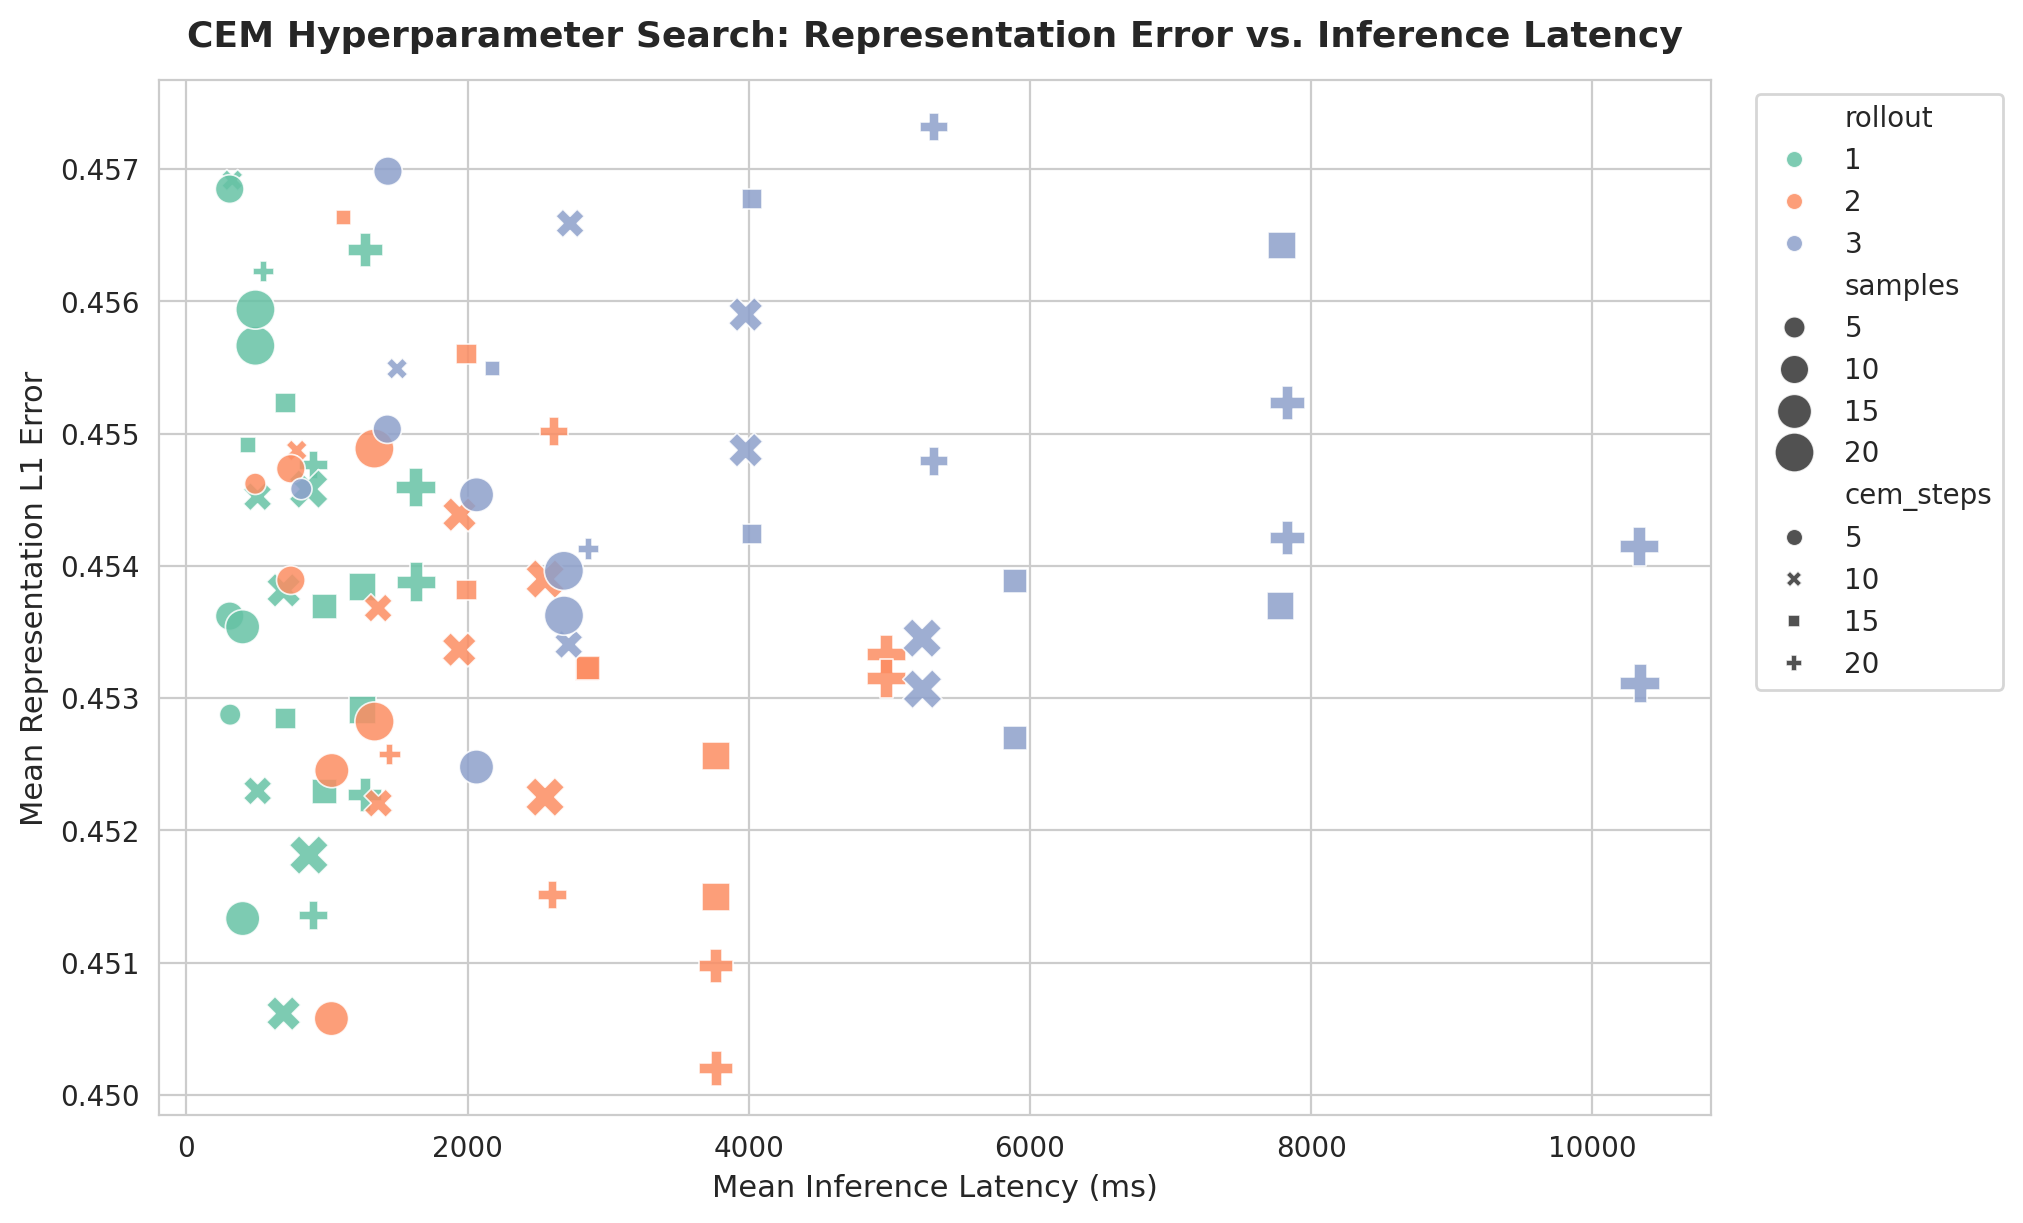

In [10]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    sns.scatterplot(
        data=df_results,
        x="mean_inference_latency_ms",
        y="mean_rep_l1_error",
        hue="rollout",
        style="cem_steps",
        size="samples",
        sizes=(60, 200),
        palette="Set2",
        alpha=0.85,
        ax=ax,
    )

    # Annotate points with parameter tags
    for _, row in df_results.iterrows():
        #label = f"R:{int(row['rollout'])}, S:{int(row['samples'])}, C:{int(row['cem_steps'])}"
        label = ""
        ax.annotate(
            label,
            (row["mean_inference_latency_ms"], row["mean_rep_l1_error"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(
        "CEM Hyperparameter Search: Representation Error vs. Inference Latency",
        fontsize=13,
        pad=12,
        weight="bold",
    )
    ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
    ax.set_ylabel("Mean Representation L1 Error", fontsize=11)

    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

    plt.show()

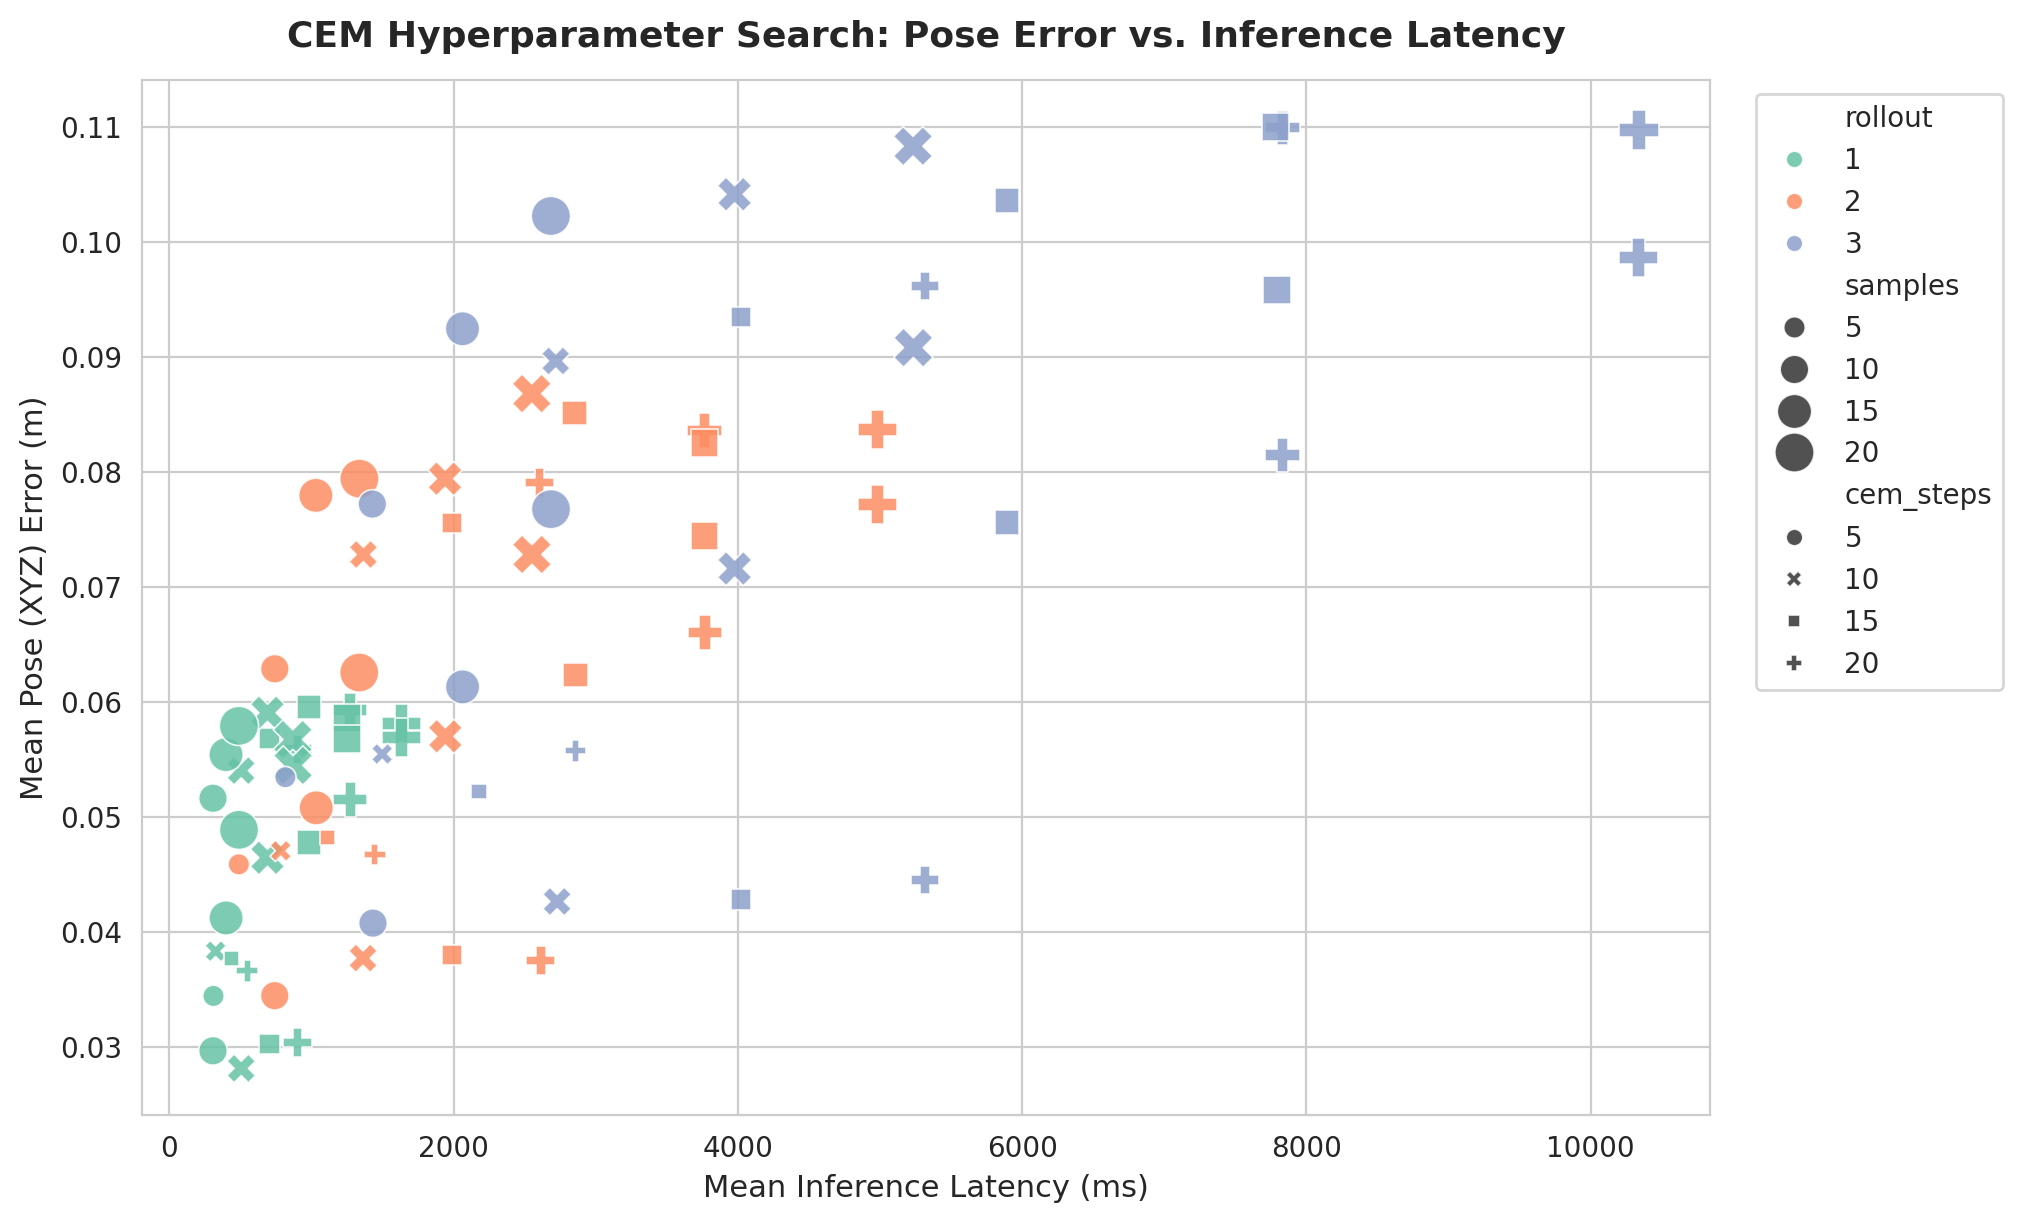

In [11]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    sns.scatterplot(
        data=df_results,
        x="mean_inference_latency_ms",
        y="mean_pose_error_m",
        hue="rollout",
        style="cem_steps",
        size="samples",
        sizes=(60, 200),
        palette="Set2",
        alpha=0.85,
        ax=ax,
    )

    # Annotate points with parameter tags
    for _, row in df_results.iterrows():
        #label = f"R:{int(row['rollout'])}, S:{int(row['samples'])}, C:{int(row['cem_steps'])}"
        label = ""
        ax.annotate(
            label,
            (row["mean_inference_latency_ms"], row["mean_pose_error_m"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(
        "CEM Hyperparameter Search: Pose Error vs. Inference Latency",
        fontsize=13,
        pad=12,
        weight="bold",
    )
    ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
    ax.set_ylabel("Mean Pose (XYZ) Error (m)", fontsize=11)

    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

    plt.show()